In [ ]:
# Import the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the data
customers = pd.read_csv("Customers.csv")
subscription = pd.read_csv("Subscriptions.csv")
transaction = pd.read_csv("Transactions.csv")
churn = pd.read_csv("Churn.csv")
customers.head(10)

,CustomerID,FirstName,LastName,Email,PhoneNumber,JoinDate,Status,Region
0,1,John,Doe,john.doe@example.com,123-456-7890,10-01-2022,Active,North America
1,2,Jane,Smith,jane.smith@example.com,098-765-4321,15-12-2021,Inactive,Europe
2,3,Alice,Johnson,alice.j@example.com,567-890-1234,20-03-2020,Active,Asia
3,4,Bob,Brown,bob.brown@example.com,234-567-8901,25-06-2019,Inactive,North America
4,5,Charlie,Davis,charlie.d@example.com,345-678-9012,14-07-2021,Active,Europe
5,6,Diana,Clark,diana.c@example.com,456-789-0123,30-08-2018,Active,Asia
6,7,Eva,Harris,eva.h@example.com,567-890-1234,22-12-2020,Inactive,North America
7,8,Frank,Garcia,frank.g@example.com,678-901-2345,11-03-2019,Active,Europe
8,9,Grace,Miller,grace.m@example.com,789-012-3456,18-02-2022,Inactive,Asia
9,10,Hank,Wilson,hank.w@example.com,890-123-4567,27-05-2020,Active,North America


In [ ]:
customer_names = customers[["FirstName","LastName"]]
customer_names.head(20)


,FirstName,LastName
0,John,Doe
1,Jane,Smith
2,Alice,Johnson
3,Bob,Brown
4,Charlie,Davis
5,Diana,Clark
6,Eva,Harris
7,Frank,Garcia
8,Grace,Miller
9,Hank,Wilson


In [ ]:
customer_north_america = customers[customers["Region"] == "North America"]
customer_north_america.head()
customer_north_america.shape

(103, 8)

Region
North America    103
Europe           100
Asia              96
Name: count, dtype: int64


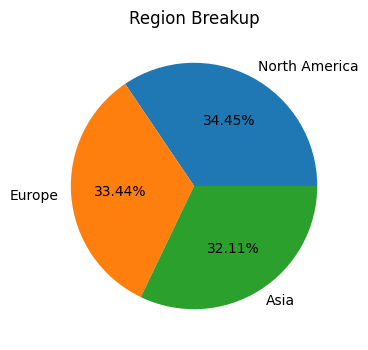

In [ ]:
# Give me the count of number of customers from different region
different_region = customers["Region"].value_counts()
print(different_region)
plt.figure(figsize=(4,4))
plt.pie(different_region, labels=different_region.index, autopct="%.2f%%")
plt.title("Region Breakup")
plt.show()


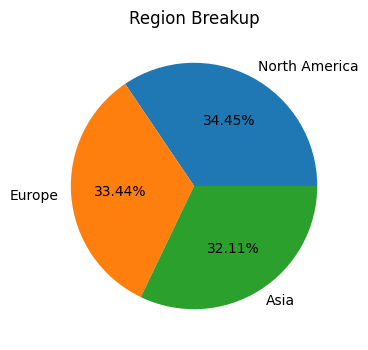

In [ ]:
# pie chart for region wise
plt.figure(figsize=(4,4))
plt.pie(different_region, labels=different_region.index, autopct="%.2f%%")
plt.title("Region Breakup")
plt.show()

In [ ]:
# Total count of customers
customers.shape[0]



300

Status
Active      152
Inactive    147
Name: count, dtype: int64


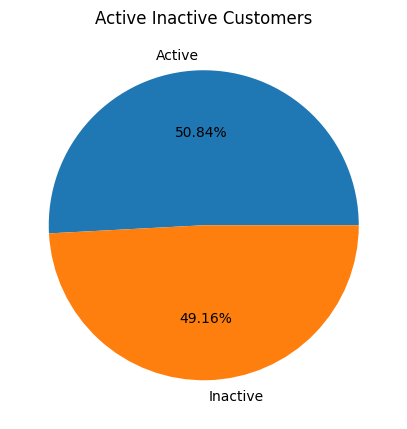

In [ ]:
# how many active vs inactive cutomer are there. % pie

status_count = customers["Status"].value_counts()
print(status_count)

plt.figure(figsize=(5,6))
plt.pie(status_count, labels=status_count.index, autopct="%.2f%%")
plt.title("Active Inactive Customers")
plt.show()

In [ ]:
# how many active customer from europe
customer_active_europe = customers[(customers["Status"] == "Active") & customers["Region"]]
customer_active_europe.shape[0]

151

In [ ]:
# Show the subscriptions with annaual plan
subscription.head(10)


,SubscriptionID,CustomerID,StartDate,EndDate,PlanType
0,1,1,10-01-2022,09-01-2023,Annual
1,2,2,15-12-2021,14-12-2022,Monthly
2,3,3,20-03-2020,19-03-2021,Annual
3,4,4,25-06-2019,24-06-2020,Annual
4,5,5,14-07-2021,13-07-2022,Monthly
5,6,6,30-08-2018,29-08-2019,Annual
6,7,7,22-12-2020,21-12-2021,Monthly
7,8,8,11-03-2019,10-03-2020,Annual
8,9,9,18-02-2022,17-02-2023,Monthly
9,10,10,27-05-2020,26-05-2021,Annual


In [ ]:
annual_plan = subscription[subscription["PlanType"] == "Annual"]
annual_plan.head()
#annual_plan.shape

,SubscriptionID,CustomerID,StartDate,EndDate,PlanType
0,1,1,10-01-2022,09-01-2023,Annual
2,3,3,20-03-2020,19-03-2021,Annual
3,4,4,25-06-2019,24-06-2020,Annual
5,6,6,30-08-2018,29-08-2019,Annual
7,8,8,11-03-2019,10-03-2020,Annual


In [ ]:
# with bar/count graph annual subscription & monthly subscription
annual_plan = subscription[subscription["PlanType"] == "Monthly"]
annual_plan.head()
annual_plan.shape

(199, 5)

/tmp/ipykernel_6634/1142585243.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="PlanType",data=subscription,palette="Set3")


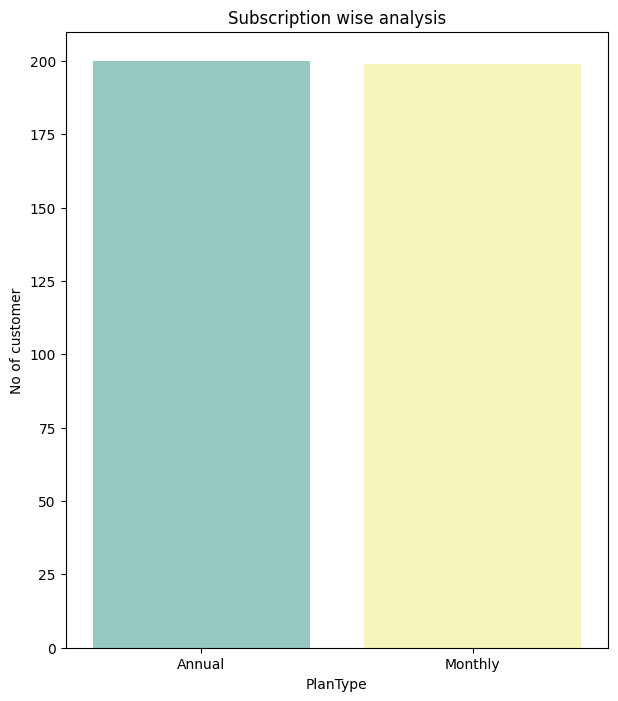

In [ ]:
plt.figure(figsize=(7,8))
sns.countplot(x="PlanType",data=subscription,palette="Set3")
plt.title("Subscription wise analysis")
plt.ylabel("No of customer")
plt.show()


/tmp/ipykernel_6634/394509732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.countplot(x="PlanType",data= subscription,palette="Set3")


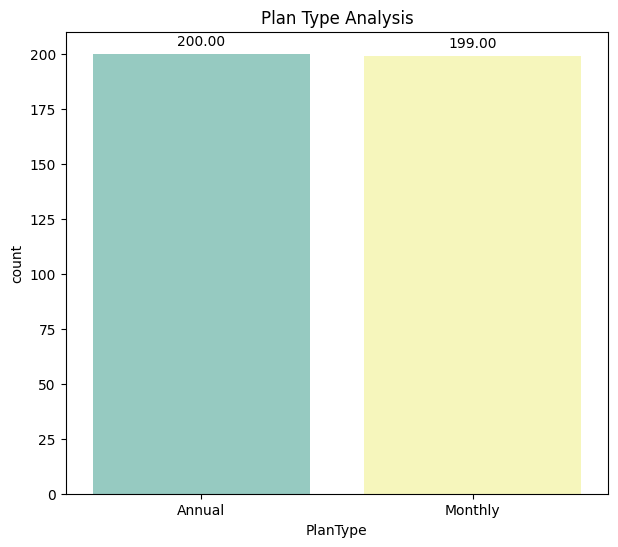

In [ ]:
plt.figure(figsize=(7,6))
a = sns.countplot(x="PlanType",data= subscription,palette="Set3")

for container in a.containers:
  a.bar_label(container,fmt="%.2f",padding = 4)
plt.title("Plan Type Analysis")
plt.show()


In [ ]:
transaction.head(10)


,TransactionID,CustomerID,TransactionDate,Amount,TransactionType
0,1,15,01-01-2024,32,Purchase
1,2,22,02-01-2024,52,Refund
2,3,43,03-01-2024,165,Purchase
3,4,87,04-01-2024,134,Purchase
4,5,34,05-01-2024,158,Purchase
5,6,56,06-01-2024,170,Refund
6,7,23,07-01-2024,196,Purchase
7,8,11,08-01-2024,195,Purchase
8,9,76,09-01-2024,143,Purchase
9,10,45,10-01-2024,69,Refund


In [ ]:
#find out how many tranaction above $100
amount_grt = transaction[transaction["Amount"]> 100]
amount_grt.shape[0]

125

In [ ]:
# create pie chart to visualise transaction above 100 and below 100
#amount_less = transaction[transaction["Amount"]<100]
#amount_less.shape[0]

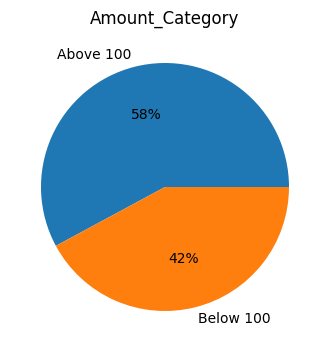

In [ ]:
# create pie chart to visualise transaction above 100 and below 100
transaction["Amount_Category"]=transaction["Amount"].apply(lambda x :"Above 100" if x>100 else "Below 100")
transaction.head()
amt_category_count = transaction["Amount_Category"].value_counts()
amt_category_count.head()
plt.figure(figsize=(4,6))
plt.pie(amt_category_count, labels=amt_category_count.index,autopct="%.0f%%")
plt.title("Amount_Category")
plt.show()


/tmp/ipykernel_6634/700756056.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.countplot(x="Amount_Category",data= transaction,palette="Set3")


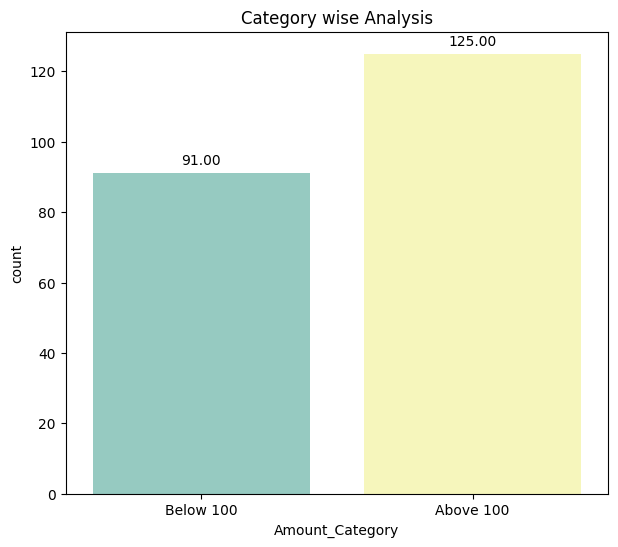

In [ ]:
# create bar/count chart to visualise transaction above 100 and below 100
category_count= transaction["Amount_Category"].value_counts()
category_count.head()
plt.figure(figsize=(7,6))
a = sns.countplot(x="Amount_Category",data= transaction,palette="Set3")
for container in a.containers:
  a.bar_label(container,fmt="%.2f", padding = 4)
plt.title("Category wise Analysis")
plt.show()


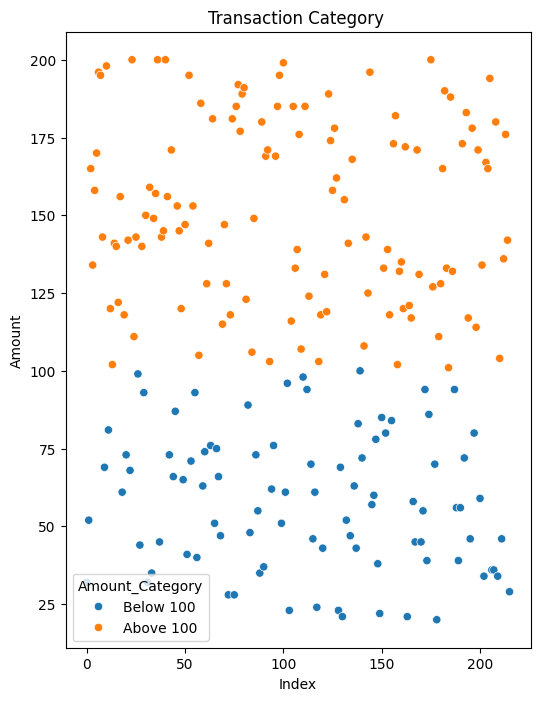

In [ ]:
# create Scatter plot to visualise transaction above 100 and below 100
amount_category_count= transaction["Amount_Category"].value_counts()
amount_category_count.head()
plt.figure(figsize=(6,8))
sns.scatterplot(x=transaction.index,y="Amount",hue="Amount_Category", data=transaction)
plt.xlabel("Index")
plt.title("Transaction Category ")
plt.show()


In [ ]:
churn.head(10)



,ChurnID,CustomerID,ChurnDate,Reason
0,1,22,02-01-2024,Poor Customer Service
1,2,56,06-06-2024,High Prices
2,3,45,10-10-2024,Product Quality Issues
3,4,54,12-12-2024,Lack of Product Features
4,5,82,14-02-2024,Competitor Offerings
5,6,67,15-01-2024,Inconvenience
6,7,17,21-01-2024,Lack of Engagement
7,8,33,18-01-2024,Unmet Expectations
8,9,91,20-01-2024,Price Increases
9,10,23,23-01-2024,Personal Circumstances


In [ ]:
# show comparision churn count and not churn count
total_customer = customers.shape[0]
total_churn = churn.shape[0]
available_customer = total_customer-total_churn
print("Total Customer",total_customer)
print("Total churn Customer",total_churn)
print("Total Available Customer",available_customer)
#available_customer

Total Customer 300
Total churn Customer 100
Total Available Customer 200


In [ ]:
# Create Data Frame to represent churned & not churned data
churn_status = pd.DataFrame({
"Status" : ["Churned","Not_Churned"],
"Count" : [total_customer,available_customer]
})
churn_status.head(10)

,Status,Count
0,Churned,300
1,Not_Churned,200


/tmp/ipykernel_6634/4108254374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Status",y="Count",data=churn_status,palette="Set3")


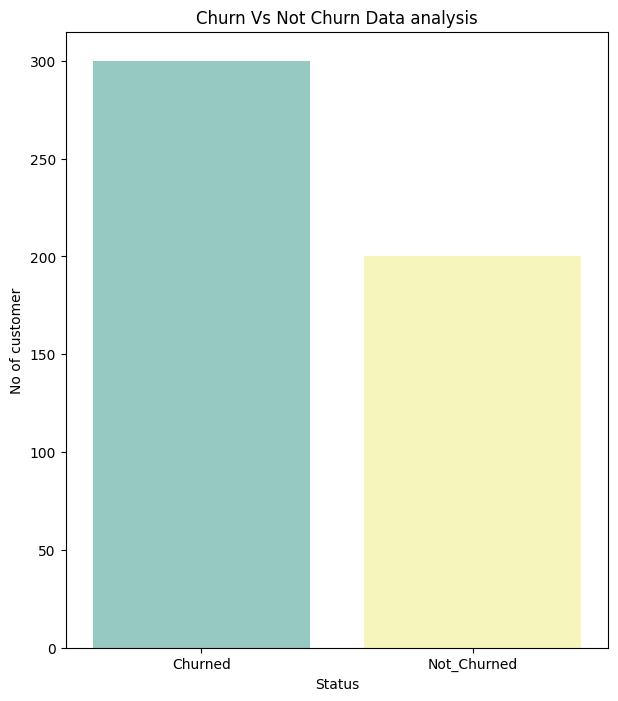

In [ ]:
plt.figure(figsize=(7,8))
sns.barplot(x="Status",y="Count",data=churn_status,palette="Set3")
for container in a.containers:
  a.bar_label(container,fmt="%.2f", padding = 4)
plt.title("Churn Vs Not Churn Data analysis")
plt.ylabel("No of customer")
plt.show()